In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df= sns.load_dataset("titanic")
#uploading the dataset to work on
# eda -> preprocessing -> data visulization -> feature engineering

In [3]:
#undertanding and checking the dataswt before deciding further about the changes (EDA)
before_col = df.columns.tolist()
before_null = df.isnull().sum().sum()
before_dupli = df.duplicated().sum()
print(df.shape) # number of rows(objects), number of columns(features/attributes)
df.head() # print the starting of the table (it's 5 by default)

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
data= df.info() #shows the main info about each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
print(df.describe()) # calculates the important descriptive data about each numerical column

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [6]:
print(df.isnull().sum()) #check how many null/missing values in each column
print(df.duplicated().sum()) #check the duplicate rows (same values)
# now for preprocessing

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
107


In [7]:
df.drop(columns=['embarked', 'who', 'alive', 'alone', 'adult_male', 'class', 'deck'], inplace=True, errors= 'ignore')
# deleting all those columns cuz they have some others with the same values/purpose

In [8]:
print(df.head()) 

   survived  pclass     sex   age  sibsp  parch     fare  embark_town
0         0       3    male  22.0      1      0   7.2500  Southampton
1         1       1  female  38.0      1      0  71.2833    Cherbourg
2         1       3  female  26.0      0      0   7.9250  Southampton
3         1       1  female  35.0      1      0  53.1000  Southampton
4         0       3    male  35.0      0      0   8.0500  Southampton


In [9]:
#checking for both mean and median for numbers cuz mean might be far off if outliers
# and mode for category, to fill them
age_median=df['age'].median()
print(age_median)
age_mean=df['age'].mean()
print('\n', age_mean)
embark_mode= df['embark_town'].mode()[0]

28.0

 29.69911764705882


In [10]:
# fillng each with the appropriate value
df['age']=df['age'].fillna(age_median)
df['embark_town']=df['embark_town'].fillna(embark_mode)

In [11]:
# checking the last time for any null/duplicated values
print(df.isnull().sum())
print(df.duplicated().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embark_town    0
dtype: int64
116


In [12]:
# deleting duplicates
df.drop_duplicates(inplace=True)

In [13]:
print(df.isnull().sum())
print(df.duplicated().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embark_town    0
dtype: int64
0


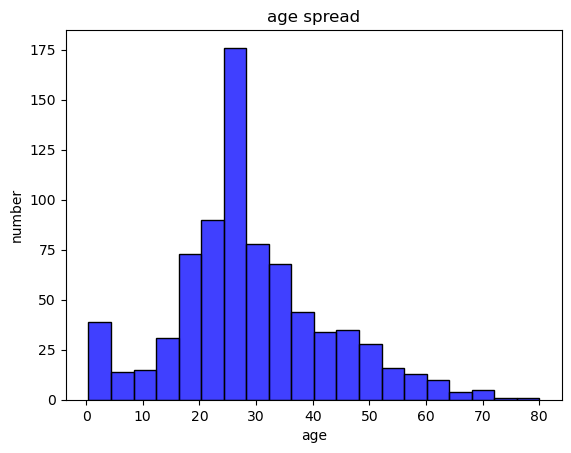

In [14]:
#data visualization 
# for example i wanna see which ages were present mostly (spread) so i'll use histogram
sns.histplot(df['age'], bins=20,color= "blue")
plt.title("age spread")
plt.xlabel("age")
plt.ylabel("number")
plt.show()

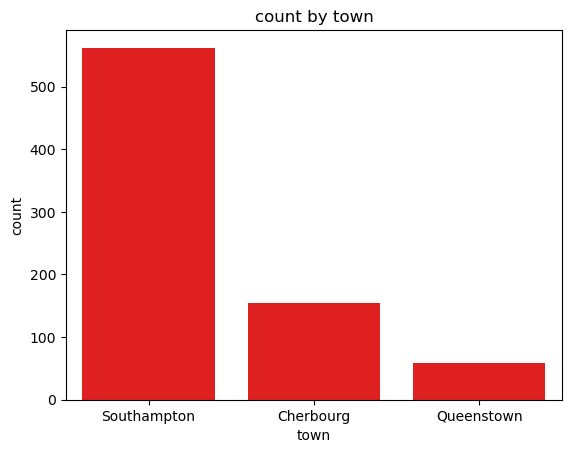

In [15]:
#maybe i wanna see where did te lower class and wealthier class go 
# so i'll use countplot to see the number from each in each category
# need to recheck this there's an error altho it's executed
sns.countplot(x='embark_town', color = 'red', data=df) 
plt.title('count by town')
plt.xlabel('town')
plt.ylabel('count')
plt.show()

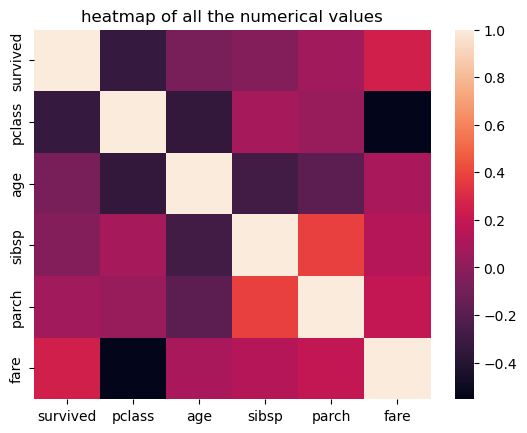

In [16]:
num_col=['survived','pclass','age','sibsp','parch','fare']
correlations= df[num_col].corr()
sns.heatmap(correlations)
plt.title('heatmap of all the numerical values')
plt.show()

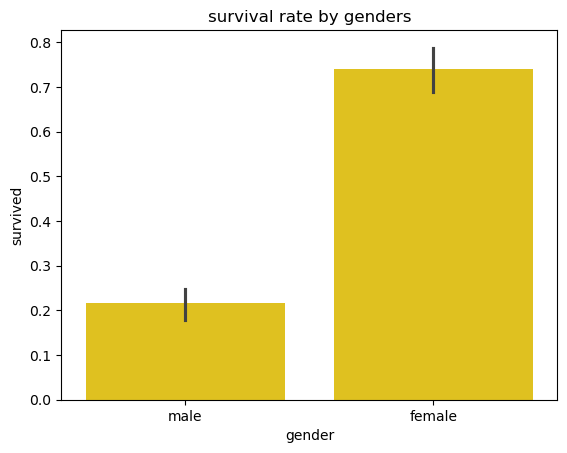

In [17]:
sns.barplot(x='sex', y='survived', data=df,color= "gold")
plt.title("survival rate by genders")
plt.xlabel("gender")
plt.ylabel("survived")
plt.show()

In [18]:
print(df.groupby('sex')['survived'].mean())
#just to check, the survival rate is corrrect since the range is between 0 and 1
# look at the rate in numbers too after this prompt, it proves the graph right (73% women survived, and 21% males)
# used boxplot to represent the relationship between a category and a numerical value, but continuous values with ditribution, so we used barplot
# heatmap compared all num values where the color represents the intensity
# countplot was used for counting a category, where Southampton was the most embarked town, followed by Cherbourg town, least being Queenstown
# histogram showed the spread of a varibale in diff values, like the most on the ship were aged around 25-30

sex
female    0.739726
male      0.215321
Name: survived, dtype: float64


In [19]:
print(df.info()) 
#convert everything to numbers for models and ml (encoding), always encode after visulization

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     775 non-null    int64  
 1   pclass       775 non-null    int64  
 2   sex          775 non-null    object 
 3   age          775 non-null    float64
 4   sibsp        775 non-null    int64  
 5   parch        775 non-null    int64  
 6   fare         775 non-null    float64
 7   embark_town  775 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 54.5+ KB
None


In [20]:
# two options = map, if 3 = one-hot encoding
df['sex']=df['sex'].map({'female':1, 'male':0})

In [21]:
df=pd.get_dummies(df,columns=['embark_town'], dtype=int)
#drop_first made 2 columns and both=0 means it's the third option that wasn't showing

In [22]:
print(df.head()) #just to confirm each is in a numerical form without errors

   survived  pclass  sex   age  sibsp  parch     fare  embark_town_Cherbourg  \
0         0       3    0  22.0      1      0   7.2500                      0   
1         1       1    1  38.0      1      0  71.2833                      1   
2         1       3    1  26.0      0      0   7.9250                      0   
3         1       1    1  35.0      1      0  53.1000                      0   
4         0       3    0  35.0      0      0   8.0500                      0   

   embark_town_Queenstown  embark_town_Southampton  
0                       0                        1  
1                       0                        0  
2                       0                        1  
3                       0                        1  
4                       0                        1  


In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   survived                 775 non-null    int64  
 1   pclass                   775 non-null    int64  
 2   sex                      775 non-null    int64  
 3   age                      775 non-null    float64
 4   sibsp                    775 non-null    int64  
 5   parch                    775 non-null    int64  
 6   fare                     775 non-null    float64
 7   embark_town_Cherbourg    775 non-null    int64  
 8   embark_town_Queenstown   775 non-null    int64  
 9   embark_town_Southampton  775 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 66.6 KB
None


In [24]:
# ML -> model training
# import scikit learn now to import models

In [25]:
x= df[['sex', 'parch', 'age', 'embark_town_Cherbourg', 'embark_town_Queenstown', 'embark_town_Southampton']] #features
y= df['survived'] #aim/goal to be predicted

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
model= LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
prediction= model.predict(x_test)

In [29]:
print(f"accuracy: {accuracy_score(y_test, prediction)}\n", f"classification report:, {classification_report(y_test, prediction)}")

accuracy: 0.8387096774193549
 classification report:,               precision    recall  f1-score   support

           0       0.86      0.88      0.87        95
           1       0.81      0.77      0.79        60

    accuracy                           0.84       155
   macro avg       0.83      0.83      0.83       155
weighted avg       0.84      0.84      0.84       155



In [30]:
after_col = df.columns.tolist()
after_null = df.isnull().sum().sum()
after_dupli = df.duplicated().sum()

In [31]:
print(f"Before:\n Columns: {before_col} \n After:\n Columns: {after_col}")
print(f"------------------------\n Before Nulls: {before_null}            |||         After Nulls: {after_null}")
print(f"-------------------------\nBefore Duplicates: {before_dupli}            |||         After Duplicates: {after_dupli}")

Before:
 Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'] 
 After:
 Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embark_town_Cherbourg', 'embark_town_Queenstown', 'embark_town_Southampton']
------------------------
 Before Nulls: 869            |||         After Nulls: 0
-------------------------
Before Duplicates: 107            |||         After Duplicates: 0
